## Latent Probing of Specific Positioned Tokens (Preliminary; 200 samples with Mistral-7B-4bit on Svamp)

We are analyzing the embeddings of last input token before model generation and the second last token in all generated tokens. We store the embeddings from all model layers.

The test run was by command `python ../semantic_uncertainty/generate_answers.py --model_name=Mistral-7B-v0.1-4bit --temperature=1 --dataset=svamp --num_samples=200`.

Note that `Mistral-7B-v0.1-4bit` does not perform well on many of the questions on SVAMP (i.e. the accuracy was low). More extensive experiments (2k generations with Falcon-7B on TrivialQA) are analyzed in the next notebook (Mar 20th). 

In [7]:
%load_ext autoreload
%autoreload 2

import os
os.chdir('/scratch-ssd/ms23jh/uncertainty/wandb/run-20240314_140138-44ihurtz/files')  
import pickle
import yaml
import json

from matplotlib import pyplot as plt
import pandas as pd
import numpy as np

import torch
import torch.nn as nn

from copy import deepcopy
import seaborn as sns

import wandb
api = wandb.Api()
api.entity = 'jiatongg'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
# Read training generated embeddings
f = open('validation_generations.pkl', 'rb')
generations = pickle.load(f)
f.close()

# Read uncertainty measures (p-true, predictive/semantic uncertainties)
g = open('uncertainty_measures.pkl', 'rb')
measures = pickle.load(g)
g.close()

In [4]:
# Basic statistics about generated embeddings
import random
print("Number of generations:", len(generations))
print("Each generation's fields:", list(generations.values())[0].keys())

random_record = list(generations.values())[random.randint(0, len(generations))]
print(random_record['question'])
print(random_record['context'])
print(random_record['most_likely_answer']['emb_last_tok_before_gen'].shape)
# (num_layers+1) * 1 tok * hidden_dim
print(random_record['most_likely_answer']['emb_tok_before_eos'].shape)
print(random_record['reference'])
print(random_record['responses'])

Number of generations: 200
Each generation's fields: dict_keys(['question', 'context', 'most_likely_answer', 'reference', 'responses'])
How many blocks are left?
Randy uses 36 blocks to build a tower. If he had 59 blocks
torch.Size([33, 1, 4096])
torch.Size([33, 1, 4096])
{'answers': {'answer_start': [], 'text': ['23.0']}, 'id': 'chal-900'}
[('44.0', [-0.011511923745274544, -2.425344944000244, -3.0810208320617676, -0.1544964611530304, -0.024889003485441208], tensor([[ 0.4543,  5.8828, -0.8066,  ...,  1.2832, -0.2216,  1.3955]],
       dtype=torch.float16), 0.0), ('3.0', [-0.011511923745274544, -2.190969944000244, -0.9078795313835144, -0.019086629152297974], tensor([[ 0.0399,  4.4492, -0.1553,  ..., -0.8989,  0.4548,  1.5693]],
       dtype=torch.float16), 0.0), ('10.0', [-0.011511923745274544, -1.0972199440002441, -2.1542508602142334, -0.19930319488048553, -0.01969250850379467], tensor([[ 0.9277,  3.0957, -1.5518,  ...,  0.9575,  0.5493,  1.2891]],
       dtype=torch.float16), 0.0), ('

In [5]:
# Check out uncertainty measures
measures.keys()

dict_keys(['uncertainty_measures', 'semantic_ids', 'validation_is_false', 'validation_unanswerable', 'alt_validation_accuracies_mean', 'alt_validation_is_false'])

In [8]:
# Check out uncertainty measures
# Use semantic entropy as initial target for training Linear Probes
semantic_entropy = torch.tensor(measures['uncertainty_measures']['semantic_entropy'])
semantic_entropy.shape

torch.Size([200])

In [9]:
# Training a simple MLP as linear probes
import torch
import torch.nn as nn
from torch.nn import Linear, ReLU, Dropout

class MLP(nn.Module):
    def __init__(self, in_dim, hid_dims, out_dim, dropout):
        super(MLP, self).__init__()
        layers = []
        
        # Check if hid_dims is a list or a scalar and construct the layer dimensions list
        if isinstance(hid_dims, int):
            # If it's a scalar, we assume a two-layer network with the same hidden dimension
            layer_dims = [in_dim] + [hid_dims] * 2
        elif isinstance(hid_dims, list):
            # If it's a list, construct layer dimensions starting with in_dim and ending with the last hidden dimension
            layer_dims = [in_dim] + hid_dims
        else:
            raise ValueError("hid_dims must be either an integer or a list of integers")
        
        for i in range(len(layer_dims) - 1):
            layers.extend([
                Linear(layer_dims[i], layer_dims[i+1]),
                ReLU(),
                Dropout(dropout)
            ])
        
        layers.append(Linear(layer_dims[-1], out_dim))        
        self.layers = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.layers(x)

## Explore Last Input Token before Generated Token

We train simple MLPs (5 layers, 50 epochs) on the token embeddings from each layer on semantic entropy scores. We save best models and test model generalization capabilities by cross-feeding layers' embeddings to models and comparing their test losses. 

**The general observation is that when two layers are further apart (e.g. layer 0 and layer 32), models trained on each are worse in cross-layer test performances. Models trained on earlier layers perform better on later layers' embeddings while later layers extrapolate worse to earlier layers.**


In [10]:
tok_bef_gen_dataset = torch.stack([record['most_likely_answer']['emb_last_tok_before_gen'] 
                                   for record in generations.values()]).squeeze(-2).to(torch.float32)
# Originally float64
semantic_entropy = semantic_entropy.to(torch.float32)

print(tok_bef_gen_dataset.shape)

torch.Size([200, 33, 4096])


In [11]:
x = tok_bef_gen_dataset[4]
x.shape, x[2], x[3]

(torch.Size([33, 4096]),
 tensor([ 6.3896e-05, -2.3212e-03, -1.1139e-03,  ..., -3.8147e-03,
         -9.0218e-04,  6.7444e-03]),
 tensor([-0.0046, -0.0081, -0.0040,  ...,  0.0021, -0.0027,  0.0128]))

### Experment layer-by-layer

In [13]:
tok_bef_gen_layered_datasets = tok_bef_gen_dataset.transpose(0, 1)
print(tok_bef_gen_layered_datasets.shape, tok_bef_gen_layered_datasets.dtype)

torch.Size([33, 200, 4096]) torch.float32


In [14]:
# Make batched inputs and dataloaders (one for each layer)
from torch.utils.data import TensorDataset, DataLoader, random_split

batch_size = 32
train_size = int(200 * 0.8)
test_size = 200 - train_size

tbg_train_dataloaders = []
tbg_test_dataloaders = []

for i in range(tok_bef_gen_layered_datasets.shape[0]):
    # Extract the i-th dataset from the layered_dataset
    dataset_i = tok_bef_gen_layered_datasets[i]
    
    tensor_dataset_i = TensorDataset(dataset_i, semantic_entropy)
    train_dataset_i, test_dataset_i = random_split(tensor_dataset_i, [train_size, test_size])
    
    train_dataloader_i = DataLoader(train_dataset_i, batch_size=batch_size, shuffle=True)
    test_dataloader_i = DataLoader(test_dataset_i, batch_size=batch_size, shuffle=False)  
    
    tbg_train_dataloaders.append(train_dataloader_i)
    tbg_test_dataloaders.append(test_dataloader_i)

In [15]:
# Function to train and evaluate the model (and save the best model for later use)
import copy
import torch.optim as optim

def train_and_evaluate(model, train_loader, test_loader, epochs=50):
    criterion = nn.MSELoss() 
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = float('inf')
    
    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        for inputs, scalars in train_loader:  # Replace "_" with your actual labels if available
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, scalars)  # Adjust targets based on your task
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()
        avg_train_loss = total_train_loss / len(train_loader)
        
        model.eval()
        total_eval_loss = 0
        with torch.no_grad():
            for inputs, scalars in test_loader: 
                outputs = model(inputs)
                loss = criterion(outputs, scalars)  # Adjust targets based on your task
                total_eval_loss += loss.item()
        avg_eval_loss = total_eval_loss / len(test_loader)
        
        # Logging for each epoch
        print(f"Epoch {epoch+1}/{epochs}, Training Loss: {avg_train_loss:.4f}, Evaluation Loss: {avg_eval_loss:.4f}")
        
        # Check if this is the best model so far
        if avg_eval_loss < best_loss:
            best_loss = avg_eval_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            print(f"New best model found at epoch {epoch+1} with Evaluation Loss: {avg_eval_loss:.4f}")
    
    # Load best model weights
    model.load_state_dict(best_model_wts)
    return model, best_loss

In [ ]:
# Model definition
in_dim = 4096   # 
hid_dims = [1024, 512, 256]
out_dim = 1    # Output dimension (scalar for semantic entropy)
dropout = 0.5  # Dropout rate

epochs = 50

tbg_best_models = []
tbg_best_losses = []
for i, (train_loader, test_loader) in enumerate(zip(tbg_train_dataloaders, tbg_test_dataloaders)):
    model = MLP(in_dim, hid_dims, out_dim, dropout)
    print(f"Training on Dataset {i+1}/{len(tbg_train_dataloaders)}")
    best_model, best_loss = train_and_evaluate(model, train_loader, test_loader, epochs)
    tbg_best_models.append(best_model)
    tbg_best_losses.append(best_loss)

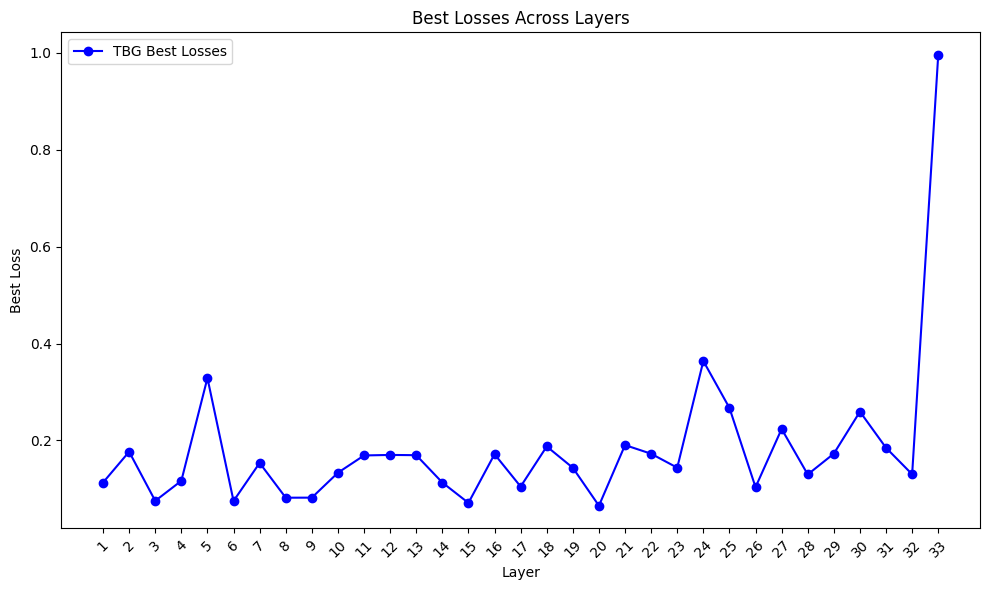

In [175]:
# Plot the best test losses across layers.
# Number of layers
num_layers = len(slt_best_losses)  # Assuming the same number of layers for both

layers = np.arange(1, num_layers + 1)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(layers, tbg_best_losses, label='TBG Best Losses', marker='o', linestyle='-', color='blue')

# Adding labels and title
plt.xlabel('Layer')
plt.ylabel('Best Loss')
plt.title('Best Losses Across Layers')

# Adding legend
plt.legend()

# Tilting x-axis labels for clarity
plt.xticks(layers, rotation=45)

# Show plot
plt.tight_layout()
plt.show()

### Test models (on one particular layer) on other layers.

Previously, we only trained and evaluated models within each layer's embedding splits ([200, 4096]). Now we would like to see the linear probe's extrapolation ability to the same token on other layers.

In [ ]:
def evaluate_model_on_loader(model, data_loader):
    model.eval()
    criterion = nn.MSELoss()
    total_loss = 0
    with torch.no_grad():
        for inputs, scalars in data_loader: 
            outputs = model(inputs)
            loss = criterion(outputs, scalars)
            total_loss += loss.item()
    avg_loss = total_loss / len(data_loader)
    return avg_loss

# Initialize a matrix to store the cross-dataset losses
tbg_cross_dataset_losses = torch.zeros(len(tbg_best_models), len(tbg_train_dataloaders) + len(tbg_test_dataloaders))

for i, model in enumerate(tbg_best_models):
    # Evaluate on training datasets
    for j, train_loader in enumerate(tbg_train_dataloaders):
        loss = evaluate_model_on_loader(model, train_loader)
        tbg_cross_dataset_losses[i, j] = loss
    # Evaluate on test datasets
    for k, test_loader in enumerate(tbg_test_dataloaders, start=len(tbg_train_dataloaders)):
        loss = evaluate_model_on_loader(model, test_loader)
        tbg_cross_dataset_losses[i, k] = loss

# Compare the cross-dataset losses with best_losses for each model
for i, (best_loss, model) in enumerate(zip(tbg_best_losses, tbg_best_models)):
    print(f"Model {i+1}:")
    print(f"  Best Loss (on its own test set): {best_loss:.4f}")
    for j in range(len(tbg_train_dataloaders)):
        print(f"  Loss on Training Dataset {j+1}: {tbg_cross_dataset_losses[i, j]:.4f}")
    for k in range(len(tbg_test_dataloaders)):
        print(f"  Loss on Test Dataset {k+1}: {tbg_cross_dataset_losses[i, len(tbg_train_dataloaders) + k]:.4f}")

**In general, the more distant a layer where the model is trained is from a test layer, the more losses in predicting SE can be observed.**

The last layer is in particular interesting (_because the last layer embeddings were obviously sharpened or scaled up compared to previous ones_; see below); models not trained on it have disproportionately high losses (though it still follows the "distance law").

In [120]:
# Last layer
layered_datasets[-1].mean(), layered_datasets[-1].var()

(tensor(-0.0118), tensor(22.0734))

In [121]:
# Layers except last layer
layered_datasets[:-1].mean(), layered_datasets[:-1].var()

(tensor(-0.0011), tensor(0.0281))

## Explore Second Last Generated Token by Model


In [160]:
sec_last_tok_dataset = torch.stack([record['most_likely_answer']['emb_tok_before_eos'] 
                                   for record in generations.values()]).squeeze(-2).to(torch.float32)
print(sec_last_tok_dataset.shape)

torch.Size([200, 33, 4096])


In [161]:
slt_layered_datasets = sec_last_tok_dataset.transpose(0, 1)
print(slt_layered_datasets.shape, slt_layered_datasets.dtype)

torch.Size([33, 200, 4096]) torch.float32


In [162]:
# Inherit from previous section (NOTE: name clashes): 
# Make batched inputs and dataloaders (one for each layer)
batch_size = 32
train_size = int(200 * 0.8)
test_size = 200 - train_size

slt_train_dataloaders = []
slt_test_dataloaders = []

for i in range(slt_layered_datasets.shape[0]):
    # Extract the i-th dataset from the layered_dataset
    dataset_i = slt_layered_datasets[i]
    
    tensor_dataset_i = TensorDataset(dataset_i, semantic_entropy)
    train_dataset_i, test_dataset_i = random_split(tensor_dataset_i, [train_size, test_size])
    
    train_dataloader_i = DataLoader(train_dataset_i, batch_size=batch_size, shuffle=True)
    test_dataloader_i = DataLoader(test_dataset_i, batch_size=batch_size, shuffle=False)  
    
    slt_train_dataloaders.append(train_dataloader_i)
    slt_test_dataloaders.append(test_dataloader_i)

In [ ]:
# Model definition
in_dim = 4096   # 
hid_dims = [1024, 512, 256]
out_dim = 1    # Output dimension (scalar for semantic entropy)
dropout = 0.5  # Dropout rate

epochs = 50

slt_best_models = []
slt_best_losses = []
for i, (train_loader, test_loader) in enumerate(zip(slt_train_dataloaders, slt_test_dataloaders)):
    model = MLP(in_dim, hid_dims, out_dim, dropout)
    print(f"Training on Second-Last-Generated-Token Dataset {i+1}/{len(train_dataloaders)}")
    best_model, best_loss = train_and_evaluate(model, train_loader, test_loader, epochs)
    slt_best_models.append(best_model)
    slt_best_losses.append(best_loss)

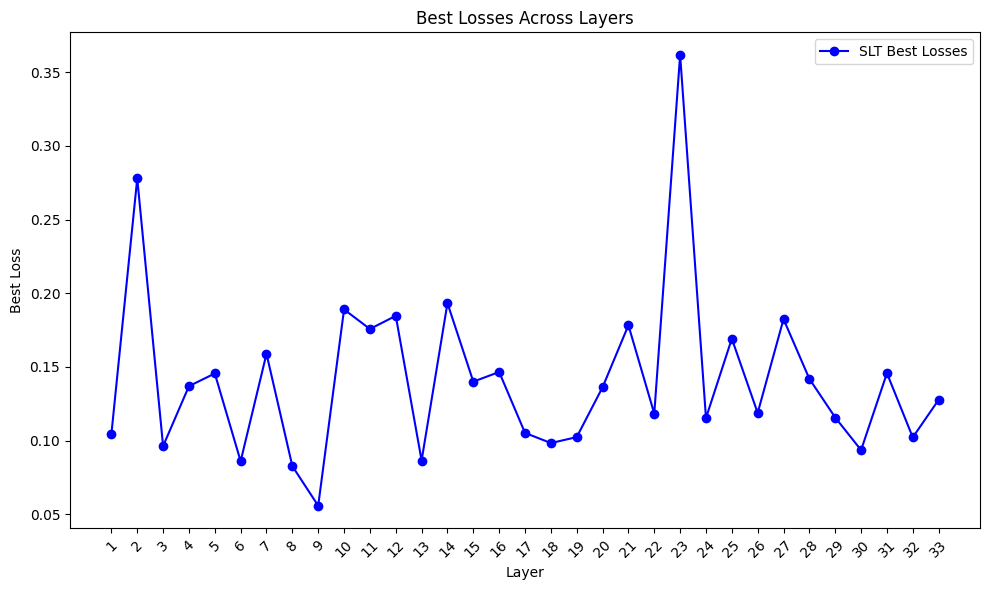

In [174]:
# Plot the best test losses across layers.
# Number of layers
num_layers = len(slt_best_losses)  # Assuming the same number of layers for both

layers = np.arange(1, num_layers + 1)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(layers, slt_best_losses, label='SLT Best Losses', marker='o', linestyle='-', color='blue')

# Adding labels and title
plt.xlabel('Layer')
plt.ylabel('Best Loss')
plt.title('Best Losses Across Layers')

# Adding legend
plt.legend()

# Tilting x-axis labels for clarity
plt.xticks(layers, rotation=45)

# Show plot
plt.tight_layout()
plt.show()

In [ ]:
slt_cross_dataset_losses = torch.zeros(len(slt_best_models), len(slt_train_dataloaders) + len(slt_test_dataloaders))

for i, model in enumerate(slt_best_models):
    for j, train_loader in enumerate(slt_train_dataloaders):
        loss = evaluate_model_on_loader(model, train_loader)
        slt_cross_dataset_losses[i, j] = loss
    for k, test_loader in enumerate(slt_test_dataloaders, start=len(slt_train_dataloaders)):
        loss = evaluate_model_on_loader(model, test_loader)
        slt_cross_dataset_losses[i, k] = loss

for i, (best_loss, model) in enumerate(zip(slt_best_losses, slt_best_models)):
    print(f"Model {i+1}:")
    print(f"  Best Loss (on its own test set): {best_loss:.4f}")
    for j in range(len(slt_train_dataloaders)):
        print(f"  Loss on Training Dataset {j+1}: {slt_cross_dataset_losses[i, j]:.4f}")
    for k in range(len(slt_test_dataloaders)):
        print(f"  Loss on Test Dataset {k+1}: {slt_cross_dataset_losses[i, len(slt_train_dataloaders) + k]:.4f}")

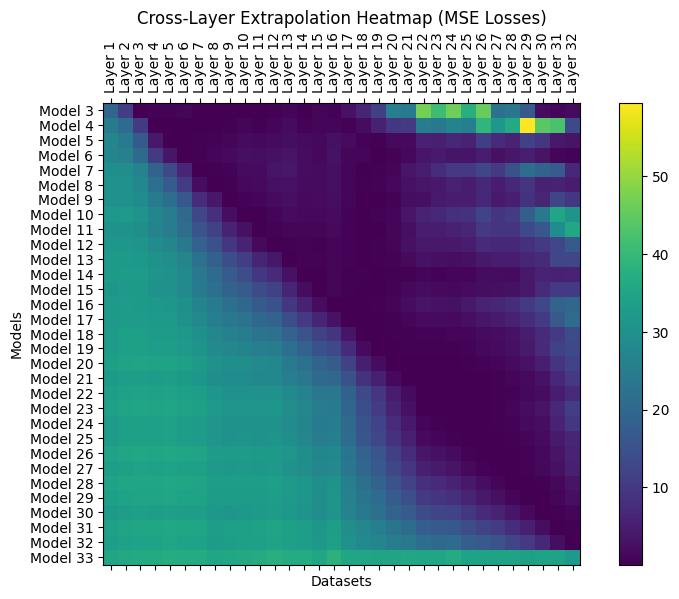

In [142]:
import matplotlib.pyplot as plt
import numpy as np

slt_cross_dataset_losses_np = slt_cross_dataset_losses[2:,len(slt_train_dataloaders):-1].numpy()

num_models = slt_cross_dataset_losses_np.shape[0]
num_datasets = slt_cross_dataset_losses_np.shape[1]

fig, ax = plt.subplots(figsize=(10, 6))
cax = ax.matshow(slt_cross_dataset_losses_np, cmap='viridis')

# Add color bar to interpret values
fig.colorbar(cax)

# Set axis labels
ax.set_xlabel('Datasets')
ax.set_ylabel('Models')
ax.set_title('Cross-Layer Extrapolation Heatmap (MSE Losses)')

# Label each axis with dataset/model numbers
ax.set_xticks(np.arange(num_datasets))
ax.set_yticks(np.arange(num_models))

ax.set_xticklabels([f'Layer {i+1}' for i in range(0, num_datasets)], rotation=90)
ax.set_yticklabels([f'Model {i+1}' for i in range(2, num_models+2)])

plt.show()

**Importantly, earlier layers trained models extrapolate better to later layers (e.g. model 3 on layer 17) except some occasional loss spikes, than how models trained on later layers extrapolate to earlier layers (e.g. model 33 on layer 1) left diagonal on the above chart).** This is a bit counter-intuitive since later layers should be more informed about earlier layers' outputs due to the network flow direction in transformers.

It would also be interesting to see how models can extrapolate across token positions (even though we have only saved information on two positions).

### Test Models across Token Positions


(SLT: second last generated token before stopping token; TBG: last input token before first generated token)

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/torch/nn/modules/loss.py:535: UserWarning: Using a target size (torch.Size([32])) that is different to the input size (torch.Size([32, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/torch/nn/modules/loss.py:535: UserWarning: Using a target size (torch.Size([8])) that is different to the input size (torch.Size([8, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


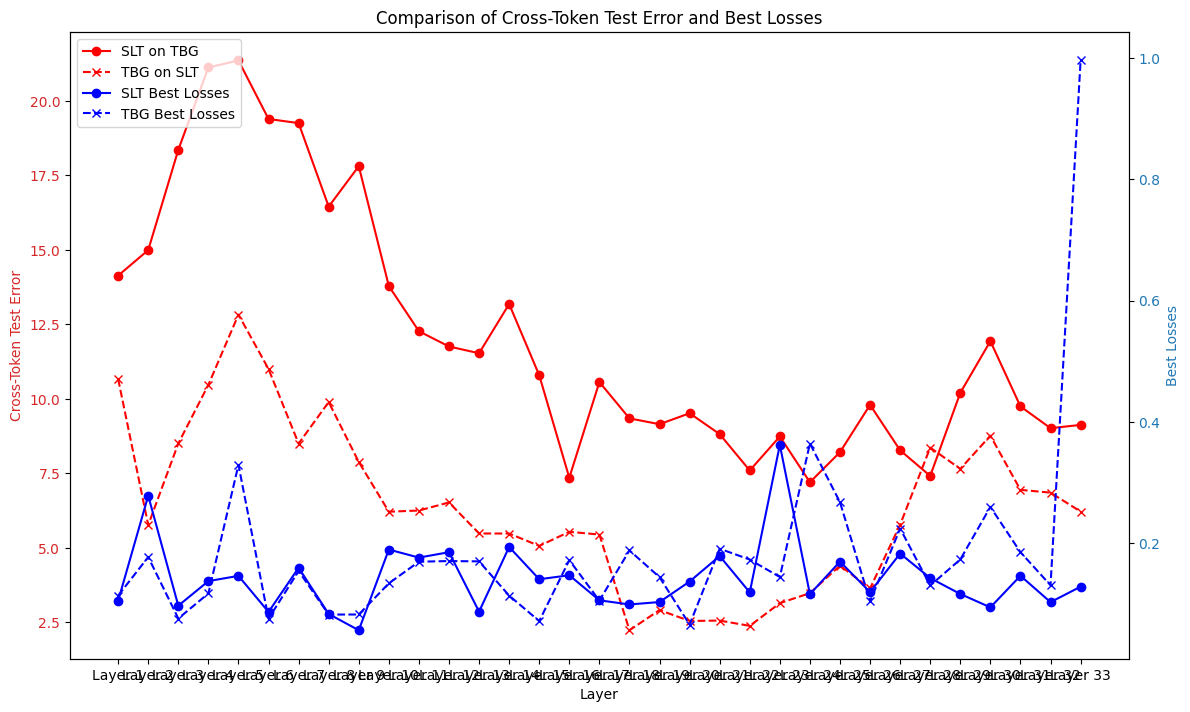

In [179]:
num_layers = len(slt_train_dataloaders)
cross_token_errors = torch.zeros(num_layers, 2)  # For storing test errors, 2 columns for each set

for i in range(num_layers):
    slt_model = slt_best_models[i]
    tbg_model = tbg_best_models[i]
    
    # Evaluate SLT model on TBG test_loader
    slt_on_tbg_loss = evaluate_model_on_loader(slt_model, tbg_test_dataloaders[i])
    cross_token_errors[i, 0] = slt_on_tbg_loss
    
    # Evaluate TBG model on SLT test_loader
    tbg_on_slt_loss = evaluate_model_on_loader(tbg_model, slt_test_dataloaders[i])
    cross_token_errors[i, 1] = tbg_on_slt_loss

# Visualization
import matplotlib.pyplot as plt
import numpy as np

fig, ax1 = plt.subplots(figsize=(12, 7))

color = 'tab:red'
ax1.set_xlabel('Layer')
ax1.set_ylabel('Cross-Token Test Error', color=color)
ax1.plot(np.arange(1, num_layers + 1), cross_token_errors[:, 0], marker='o', color='r', linestyle='-', label='SLT on TBG')
ax1.plot(np.arange(1, num_layers + 1), cross_token_errors[:, 1], marker='x', color='r', linestyle='--', label='TBG on SLT')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Best Losses', color=color)  
ax2.plot(np.arange(1, num_layers + 1), slt_best_losses, marker='o', color='b', linestyle='-', label='SLT Best Losses')
ax2.plot(np.arange(1, num_layers + 1), tbg_best_losses, marker='x', color='b', linestyle='--', label='TBG Best Losses')
ax2.tick_params(axis='y', labelcolor=color)

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc=0)

fig.tight_layout()  
plt.title('Comparison of Cross-Token Test Error and Best Losses')
plt.xticks(np.arange(1, num_layers + 1), [f'Layer {i}' for i in range(1, num_layers + 1)], rotation=45)  # Tilting x-axis labels by 45 degrees
plt.show()

In general, SLT-trained models generalize (to TBG's token position) worse than TBG-trained models (to SLT's token position), especially on eariler layers.